Create a Basic Neural Network Model

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
#create a model class that inherits nn.Module
class Model(nn.Module):
    #Input Layer (4 features of the flower)
    #Hidden Layer 1 (number of neurons)
    #Hidden Layer 2 (number of neurons)
    #Output (3 classes of iris flowers)
    def __init__(self,in_features=4,h1=8,h2=9,out_features=3):
        super().__init__()
        self.fc1 = nn.Linear(in_features,h1)
        self.fc2 = nn.Linear(h1,h2)
        self.out = nn.Linear(h2,out_features)
        
    def forward(self,x):
        x = F.relu(self.fc1(x)) 
        x = F.relu(self.fc2(x))
        x = self.out(x)
        
        return x    

In [3]:
#pick a manual seed for randomization 
torch.manual_seed(41)
#create an instance of model
model = Model()

Load Data and Train Neural Network Model

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
my_df = pd.read_csv(url)

In [6]:
my_df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [7]:
#change last column from strings to integers
my_df['species'] = my_df['species'].replace('setosa',0.0)
my_df['species'] = my_df['species'].replace('versicolor',1.0)
my_df['species'] = my_df['species'].replace('virginica',2.0)
my_df

C:\Users\hp\AppData\Local\Temp\ipykernel_18856\2703910470.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['species'] = my_df['species'].replace('virginica',2.0)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [8]:
#Train & Test split
x = my_df.drop('species',axis=1)
y = my_df['species']

In [9]:
#convert these to numpy arrays
x = x.values
y = y.values

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
# train set is 80% & test set is 20%
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=41)

In [12]:
# convert x features and y labels to tensors
x_train = torch.FloatTensor(x_train)
x_test = torch.FloatTensor(x_test)

y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [13]:
# set the criterion of model to measure the error, how far off the predictions are frim the data
criterion = nn.CrossEntropyLoss()
#choose Adam Optimizer, lr = learning rate (if error dosen't go down after a bunch of iterations(epochs), lower our lr)
optimizer = torch.optim.Adam(model.parameters(),lr=0.01)


In [14]:
#Train our model
#Epochs? (one run thru all the training data in our network)
epochs = 100
losses = []
for i in range(epochs):
    #go forward and get a prediction 
    y_pred = model.forward(x_train)
    
    #measure the loss/error,it is gonna be high at first
    loss = criterion(y_pred,y_train) #predicted values vs the y_train
    
    #keep track of our losses
    losses.append(loss.detach().numpy())
    
    #print every 10 epoch
    if i % 10==0:
        print(f'Epoch: {i} and loss: {loss}')
        
    # Do back propagation : take the error rate and feed it back
    #thru the network to fine tune the weights
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch: 0 and loss: 1.1251550912857056
Epoch: 10 and loss: 1.0096259117126465
Epoch: 20 and loss: 0.8157405853271484
Epoch: 30 and loss: 0.585706353187561
Epoch: 40 and loss: 0.3999636471271515
Epoch: 50 and loss: 0.26768800616264343
Epoch: 60 and loss: 0.17942361533641815
Epoch: 70 and loss: 0.12151690572500229
Epoch: 80 and loss: 0.0860118716955185
Epoch: 90 and loss: 0.06520851701498032


Text(0.5, 0, 'Epoch')

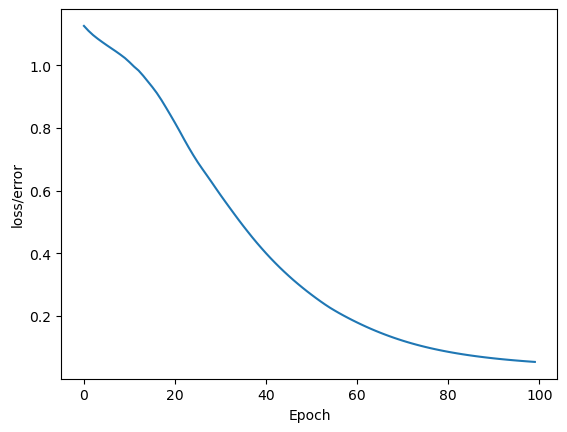

In [15]:
# Graph 
plt.plot(range(epochs),losses)
plt.ylabel("loss/error")
plt.xlabel("Epoch")

Evaluate Test Data Set On Network


In [17]:
#Evaluate model on Test data set (validate model on test set)
with torch.no_grad(): # Basically turn off back propogation
    y_eval = model.forward(x_test)
    loss = criterion(y_eval,y_test) 


In [18]:
loss

tensor(0.1315)

In [37]:
correct = 0
with torch.no_grad():
    for i, data in enumerate(x_test):
        y_val = model(data)
        prediction = y_val.argmax().item()
        actual = y_test[i].item()
        
        if y_test[i] == 0 :
            x = 'Setosa'
        elif y_test[i] == 1 :
            x = 'Versicolor' 
        else:
            x = 'Virginica'               
        
        print(f'{i+1}.) predicted: {prediction}  \tactual: {actual} \t{x} ')
        
        if prediction == actual:
            correct += 1
            
    print(f'we got {correct} correct out of {len(y_test)}!')
    print(f'Accuracy: {correct / len(y_test) * 100:.2f}%')

1.) predicted: 2  	actual: 2 	Virginica 
2.) predicted: 2  	actual: 2 	Virginica 
3.) predicted: 2  	actual: 2 	Virginica 
4.) predicted: 1  	actual: 1 	Versicolor 
5.) predicted: 2  	actual: 2 	Virginica 
6.) predicted: 1  	actual: 1 	Versicolor 
7.) predicted: 2  	actual: 2 	Virginica 
8.) predicted: 1  	actual: 1 	Versicolor 
9.) predicted: 2  	actual: 2 	Virginica 
10.) predicted: 2  	actual: 2 	Virginica 
11.) predicted: 2  	actual: 2 	Virginica 
12.) predicted: 0  	actual: 0 	Setosa 
13.) predicted: 0  	actual: 0 	Setosa 
14.) predicted: 1  	actual: 1 	Versicolor 
15.) predicted: 0  	actual: 0 	Setosa 
16.) predicted: 1  	actual: 2 	Virginica 
17.) predicted: 0  	actual: 0 	Setosa 
18.) predicted: 2  	actual: 1 	Versicolor 
19.) predicted: 0  	actual: 0 	Setosa 
20.) predicted: 0  	actual: 0 	Setosa 
21.) predicted: 1  	actual: 1 	Versicolor 
22.) predicted: 2  	actual: 2 	Virginica 
23.) predicted: 0  	actual: 0 	Setosa 
24.) predicted: 0  	actual: 0 	Setosa 
25.) predicted: 1  

Evaluate NEW Data On The Network

In [40]:
# create new data
new_iris = torch.tensor([4.7,3.2,1.3,0.2])

In [42]:
with torch.no_grad():
 print(model(new_iris))

tensor([ 4.5365, -2.2383, -2.8684])


In [32]:
newer_iris = torch.tensor([5.9,3.0,5.1,1.8])

In [33]:
with torch.no_grad():
 print(model(newer_iris))

tensor([-5.9944,  4.5077,  6.6792])


Save and Load our Neural Network Model 

In [ ]:
#save 
torch.save(model.state_dict(), 'my_iris_model.pt')

In [35]:
#load
new_model = Model()
new_model.load_state_dict(torch.load('my_iris_model.pt'))

C:\Users\hp\AppData\Local\Temp\ipykernel_18856\1690951285.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  new_model.load_state_dict(torch.load('my_iris_model.pt'))


<All keys matched successfully>

In [36]:
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)